# Exploratory Data Analysis
## Give Me Some Credit

This notebook covers the EDA phase of the project. The goal here is not to build a model but to understand the data thoroughly before we get there. We need to know what we are working with, what problems exist, which features look promising, and what decisions we should carry into modelling.

Work through each section in order and write down your observations as you go. The markdown cells at the end of each section are there for that purpose.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

%matplotlib inline

In [3]:
df = pd.read_csv(r'..\data\cs-training.csv', index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


---
## Task 1: Target Variable Analysis

The first thing to look at is the target variable. Before anything else, we need to know what we are predicting and how the classes are distributed. This shapes every decision that follows, from which evaluation metric to use to whether we need to do anything special during modelling to account for class imbalance.

In [5]:
# Value counts and percentages
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_pct
})

target_summary.reset_index()

,SeriousDlqin2yrs,Count,Percentage
0,0,139974,93.3160
1,1,10026,6.6840


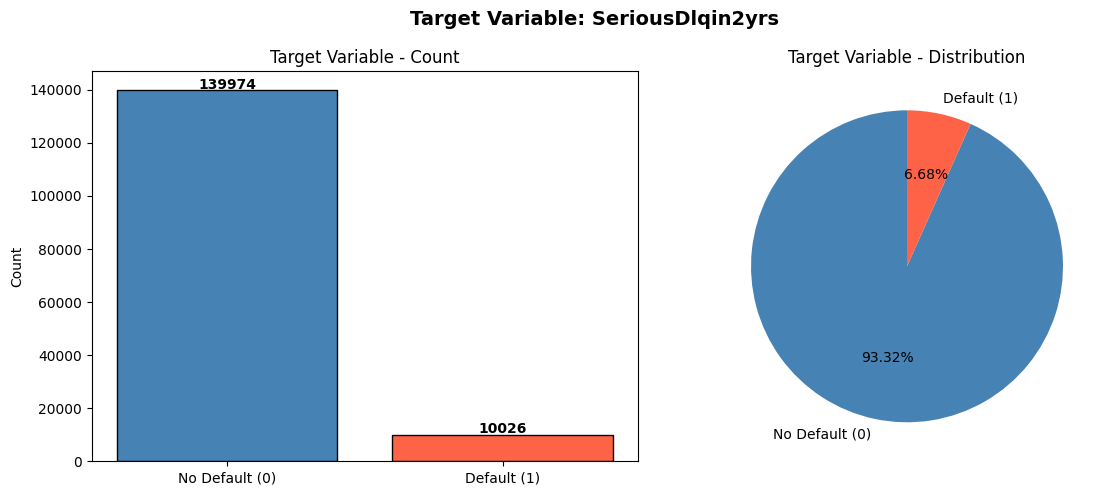

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['No Default (0)', 'Default (1)'], target_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Target Variable - Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Default (0)', 'Default (1)'],
            autopct='%1.2f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Target Variable - Distribution')

plt.suptitle('Target Variable: SeriousDlqin2yrs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**

*(Write your observations here. Is the dataset balanced? What does the imbalance ratio look like? What does this mean for how we evaluate the model?)*

---
## Task 2: Descriptive Statistics

Before plotting anything, it is worth sitting with the raw numbers for a moment. Descriptive statistics give a first look at the scale, spread, and range of every variable. They are often the fastest way to catch something suspicious before spending time on visualizations.

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0000,0.0668,0.2497,0.0000,0.0000,0.0000,0.0000,1.0000
RevolvingUtilizationOfUnsecuredLines,150000.0000,6.0484,249.7554,0.0000,0.0299,0.1542,0.5590,50708.0000
age,150000.0000,52.2952,14.7719,0.0000,41.0000,52.0000,63.0000,109.0000
NumberOfTime30-59DaysPastDueNotWorse,150000.0000,0.4210,4.1928,0.0000,0.0000,0.0000,0.0000,98.0000
DebtRatio,150000.0000,353.0051,2037.8185,0.0000,0.1751,0.3665,0.8683,329664.0000
MonthlyIncome,120269.0000,6670.2212,14384.6742,0.0000,3400.0000,5400.0000,8249.0000,3008750.0000
NumberOfOpenCreditLinesAndLoans,150000.0000,8.4528,5.1460,0.0000,5.0000,8.0000,11.0000,58.0000
NumberOfTimes90DaysLate,150000.0000,0.2660,4.1693,0.0000,0.0000,0.0000,0.0000,98.0000
NumberRealEstateLoansOrLines,150000.0000,1.0182,1.1298,0.0000,0.0000,1.0000,2.0000,54.0000
NumberOfTime60-89DaysPastDueNotWorse,150000.0000,0.2404,4.1552,0.0000,0.0000,0.0000,0.0000,98.0000


In [13]:
# Row count vs non-null count per column
print('Total rows:', len(df))
print()
print(df.count())

Total rows: 150000

SeriousDlqin2yrs                        150000
RevolvingUtilizationOfUnsecuredLines    150000
age                                     150000
NumberOfTime30-59DaysPastDueNotWorse    150000
DebtRatio                               150000
MonthlyIncome                           120269
NumberOfOpenCreditLinesAndLoans         150000
NumberOfTimes90DaysLate                 150000
NumberRealEstateLoansOrLines            150000
NumberOfTime60-89DaysPastDueNotWorse    150000
NumberOfDependents                      146076
dtype: int64


In [14]:
# Mean vs median comparison to get an early sense of skewness
mean_median = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Difference': df.mean(numeric_only=True) - df.median(numeric_only=True)
})

print(mean_median)

                                          Mean    Median  Difference
SeriousDlqin2yrs                        0.0668    0.0000      0.0668
RevolvingUtilizationOfUnsecuredLines    6.0484    0.1542      5.8943
age                                    52.2952   52.0000      0.2952
NumberOfTime30-59DaysPastDueNotWorse    0.4210    0.0000      0.4210
DebtRatio                             353.0051    0.3665    352.6386
MonthlyIncome                        6670.2212 5400.0000   1270.2212
NumberOfOpenCreditLinesAndLoans         8.4528    8.0000      0.4528
NumberOfTimes90DaysLate                 0.2660    0.0000      0.2660
NumberRealEstateLoansOrLines            1.0182    1.0000      0.0182
NumberOfTime60-89DaysPastDueNotWorse    0.2404    0.0000      0.2404
NumberOfDependents                      0.7572    0.0000      0.7572


**Observations:**

*(Which columns stand out from the summary statistics? Are there any minimum or maximum values that seem wrong? Where is the mean far from the median and what does that suggest?)*

---
## Task 3: Missing Value Analysis

Missing values need to be understood before we can decide what to do with them. We need to know which columns are affected, how much data is missing, and whether the missingness itself carries any information about the target. That last point is easy to overlook but it matters.

In [15]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_pct
}).sort_values('Missing Percentage', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

                    Missing Count  Missing Percentage
MonthlyIncome               29731             19.8207
NumberOfDependents           3924              2.6160


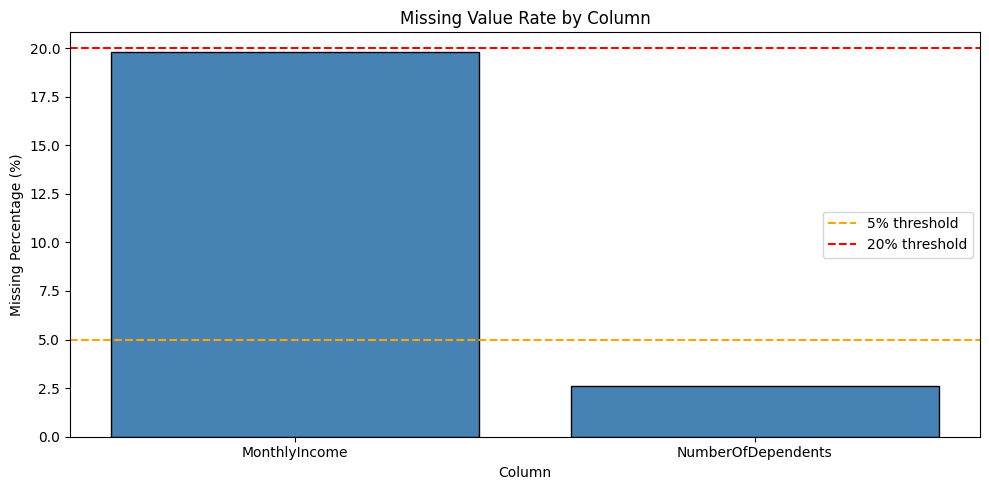

In [16]:
# Bar chart of missing percentages
cols_with_missing = missing_df.index.tolist()

if len(cols_with_missing) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(cols_with_missing, missing_df['Missing Percentage'], color='steelblue', edgecolor='black')
    plt.axhline(y=5, color='orange', linestyle='--', label='5% threshold')
    plt.axhline(y=20, color='red', linestyle='--', label='20% threshold')
    plt.title('Missing Value Rate by Column')
    plt.ylabel('Missing Percentage (%)')
    plt.xlabel('Column')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

**Observations:**

*(Which columns have missing values? Is the rate low enough to impute, or high enough to consider dropping the column? What might explain why these specific columns have missing data?)*

---
## Task 4: Distribution Analysis of All Features

Now we look at the shape of each feature. The distribution tells us how values are spread across the range, whether the data is symmetric or skewed, and whether there are unusual peaks or long tails. This is important because different models handle differently shaped data in different ways.

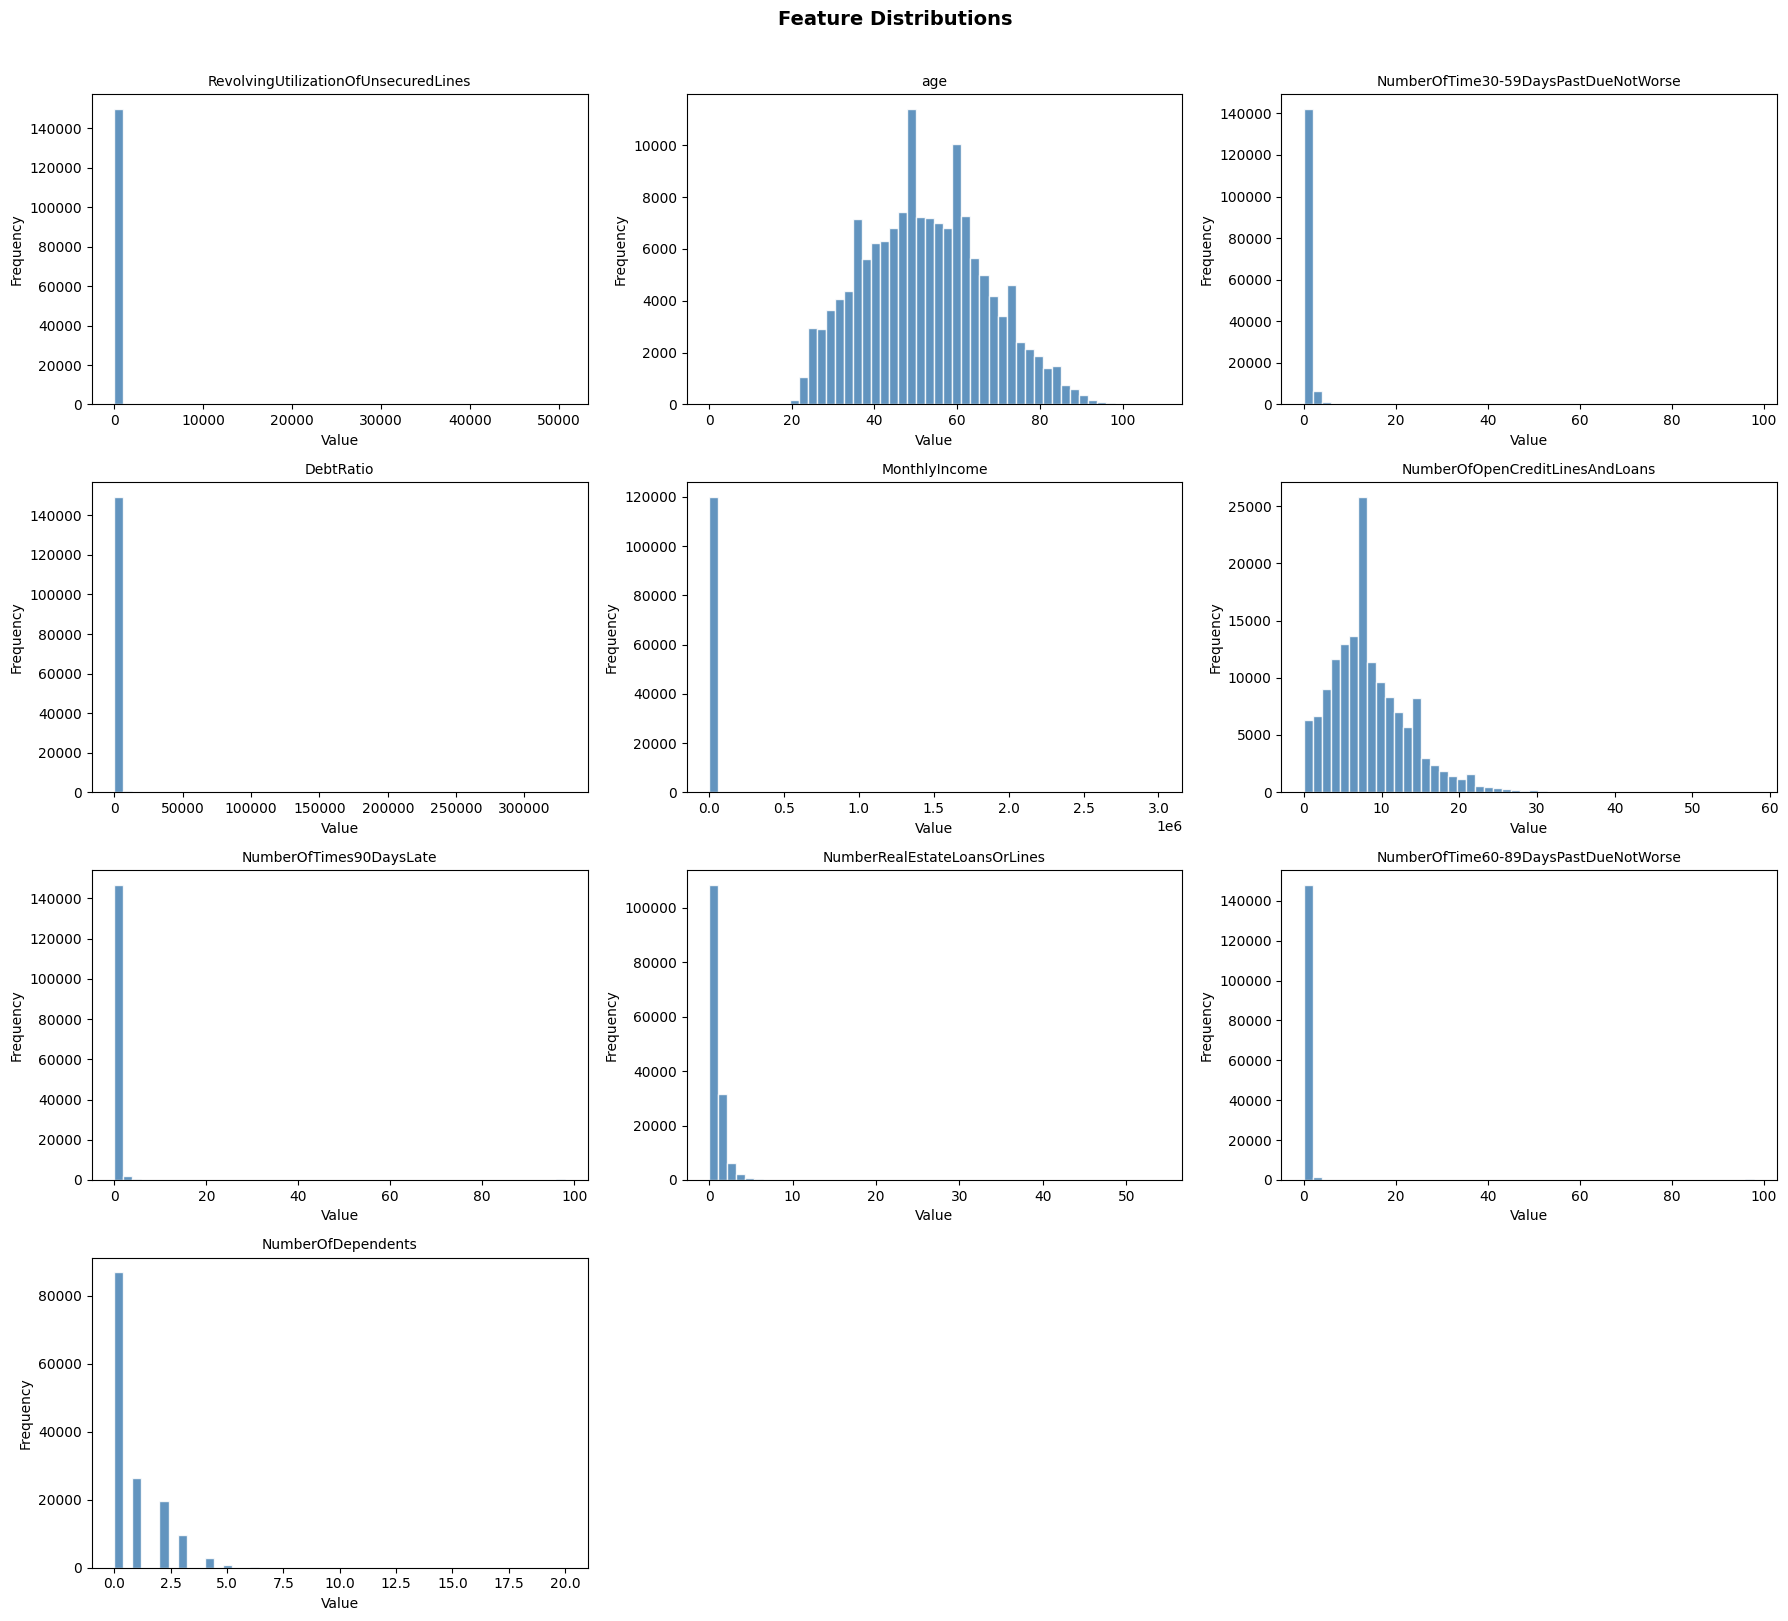

In [17]:
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']

n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

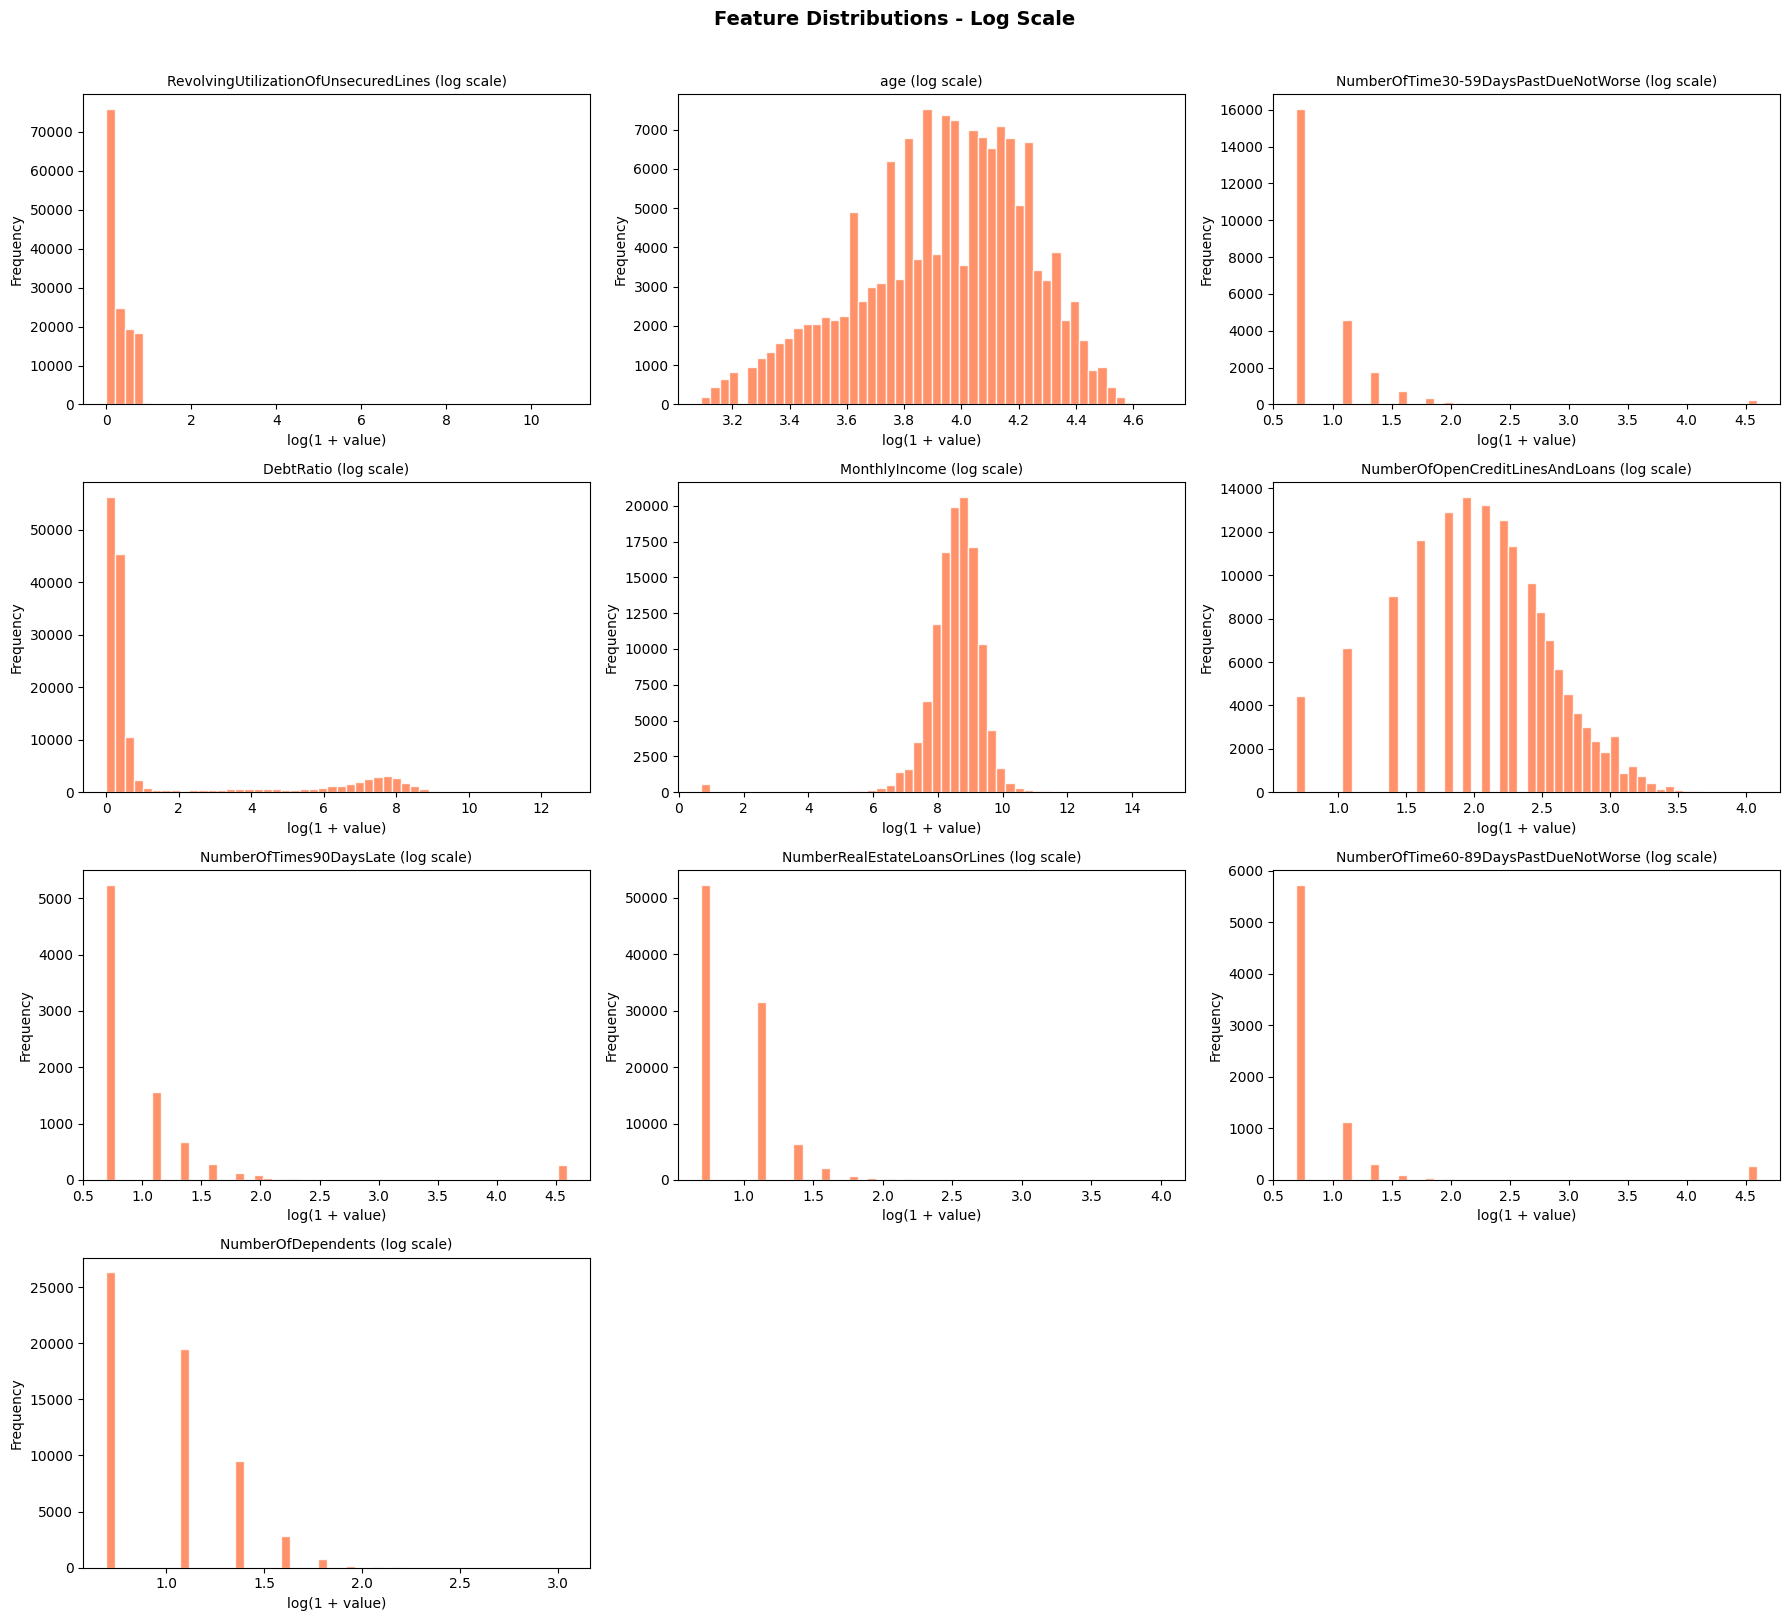

In [18]:
# Log-scale distributions for features with long tails
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df[col].dropna()
    data_positive = data[data > 0]
    if len(data_positive) > 0:
        axes[i].hist(np.log1p(data_positive), bins=50, color='coral', edgecolor='white', alpha=0.85)
        axes[i].set_title(col + ' (log scale)', fontsize=10)
        axes[i].set_xlabel('log(1 + value)')
        axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions - Log Scale', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations:**

*(Which features are heavily skewed? Are there features with a spike at zero? Do any features look roughly normal? How does the log-scale view change your interpretation?)*

---
## Task 5: Outlier Detection

Outliers come in two types. Some are genuine extreme values that are rare but real. Others are data errors, miscoded entries, or sentinel values that someone used as a placeholder. Knowing which type you are dealing with changes what you do about them.

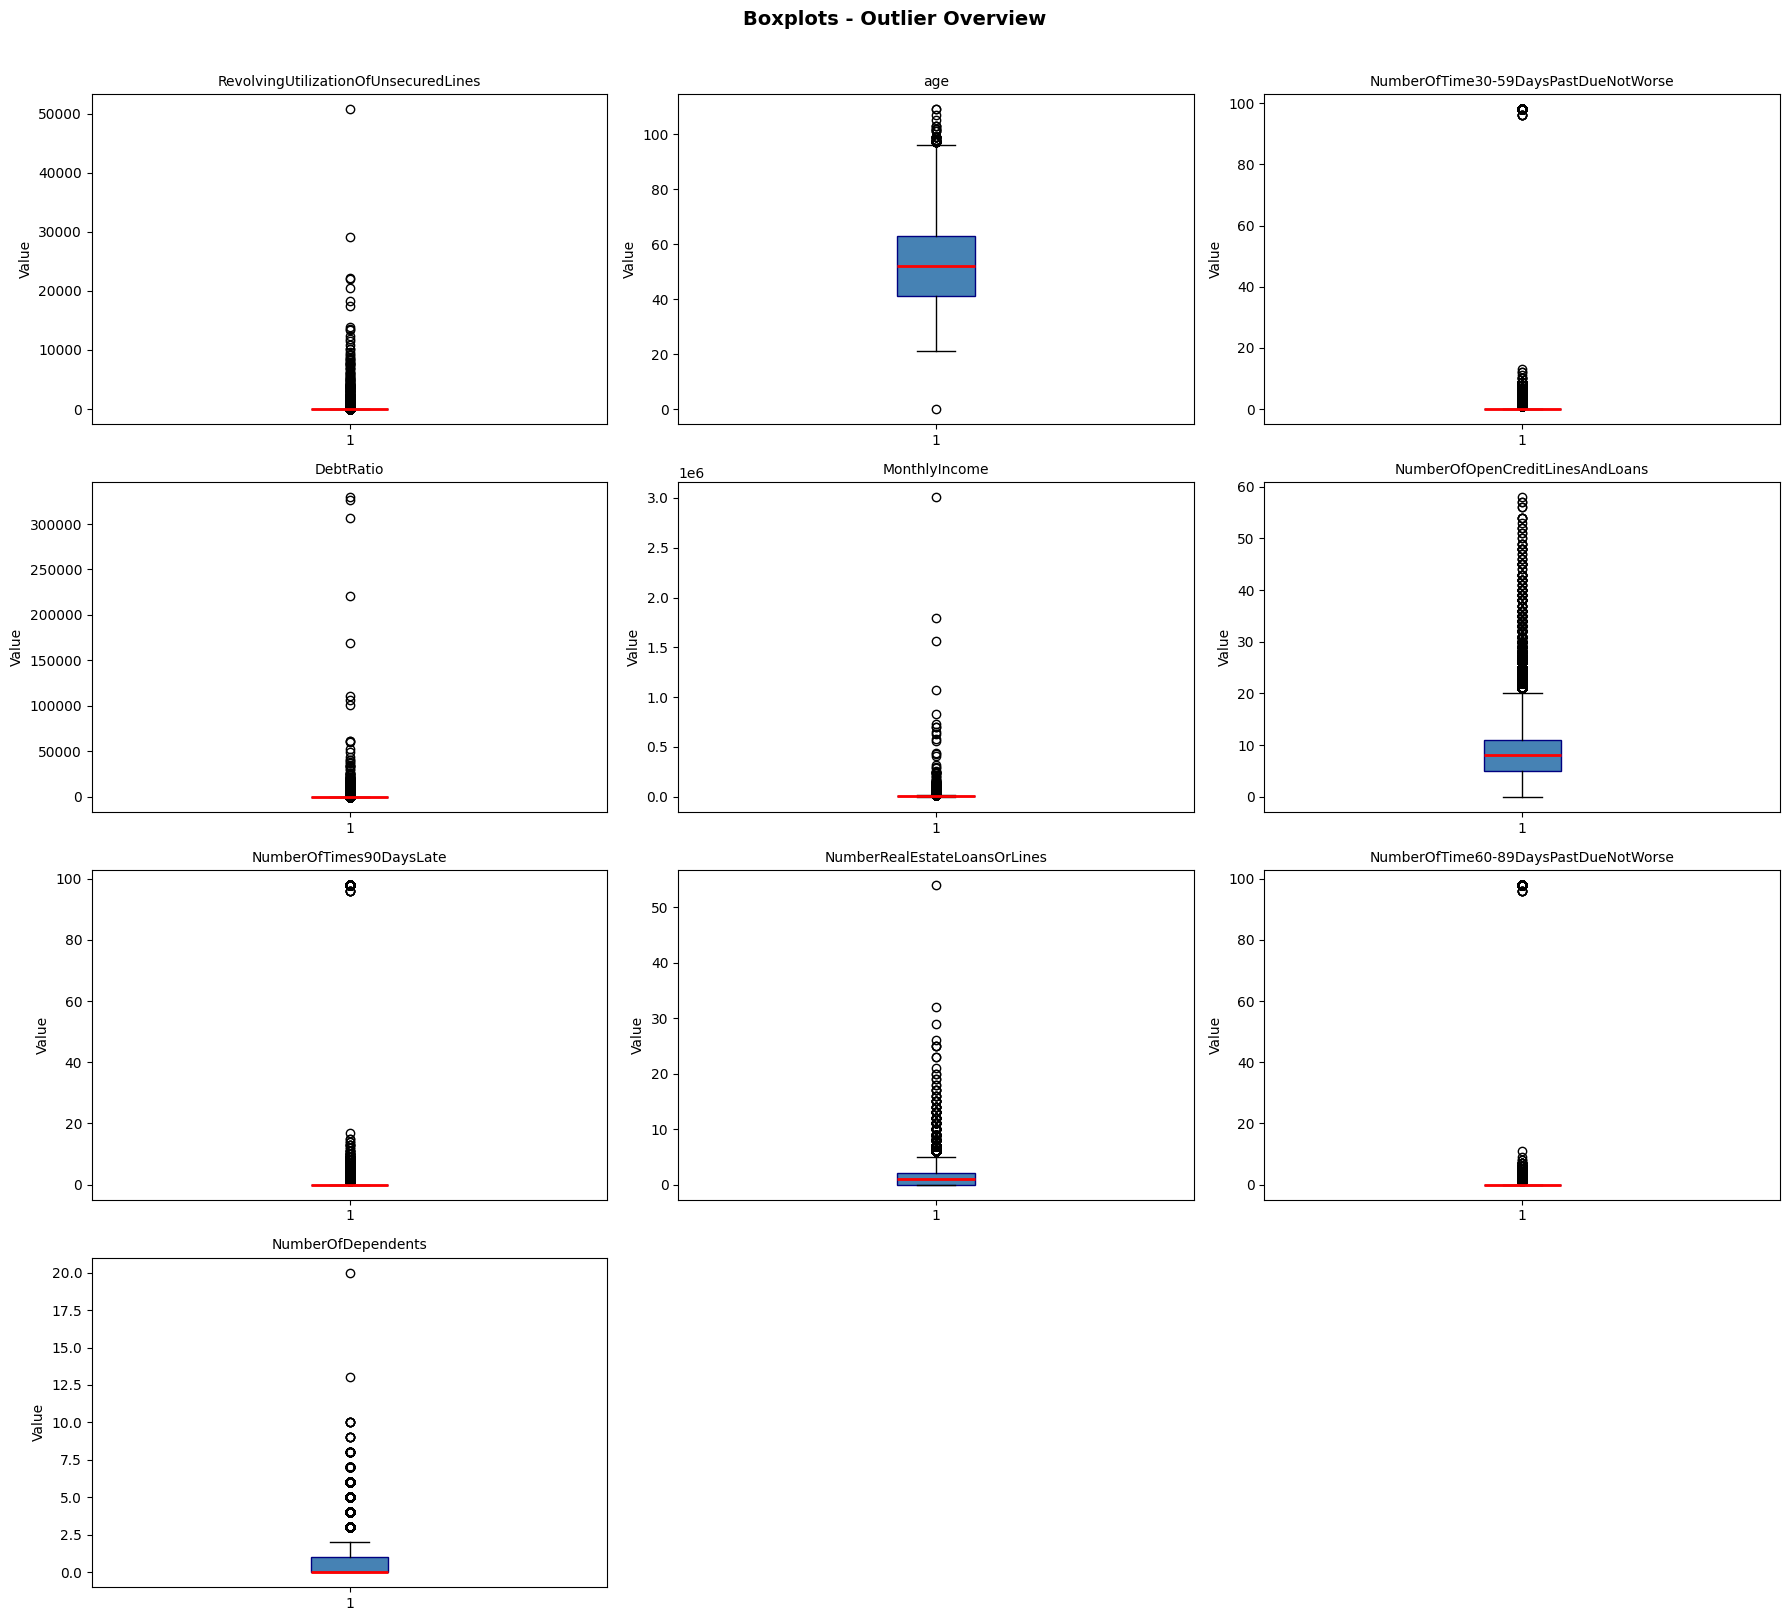

In [19]:
# Boxplots for all features
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Outlier Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# IQR-based outlier counts per feature
outlier_summary = []

for col in features:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data < lower) | (data > upper)).sum()
    pct_outliers = n_outliers / len(data) * 100
    outlier_summary.append({
        'Feature': col,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': n_outliers,
        'Outlier Pct': round(pct_outliers, 3)
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('Feature')
print(outlier_df.sort_values('Outlier Pct', ascending=False))

                                      Lower Bound  Upper Bound  Outlier Count  \
Feature                                                                         
DebtRatio                                 -0.8647       1.9080          31311   
NumberOfTime30-59DaysPastDueNotWorse       0.0000       0.0000          23982   
NumberOfDependents                        -1.5000       2.5000          13336   
NumberOfTimes90DaysLate                    0.0000       0.0000           8338   
NumberOfTime60-89DaysPastDueNotWorse       0.0000       0.0000           7604   
MonthlyIncome                          -3873.5000   15522.5000           4879   
NumberOfOpenCreditLinesAndLoans           -4.0000      20.0000           3980   
NumberRealEstateLoansOrLines              -3.0000       5.0000            793   
RevolvingUtilizationOfUnsecuredLines      -0.7639       1.3528            763   
age                                        8.0000      96.0000             46   

                           

In [32]:
df.age.nlargest(10, keep = 'first')

105791    109
138292    109
40008     107
56762     105
19885     103
57968     103
135026    103
25562     102
90938     102
96451     102
Name: age, dtype: int64

In [35]:
df.sort_values(by = 'age', ascending = False).age.unique()[:10]

array([109, 107, 105, 103, 102, 101,  99,  98,  97,  96])

In [23]:
# Check extreme values for each feature
print('Top 10 largest values per feature')
print('='*60)
for col in features:
    print(f'\n{col}:')
    print(df[col].nlargest(10).values)

Top 10 largest values per feature

RevolvingUtilizationOfUnsecuredLines:
[50708. 29110. 22198. 22000. 20514. 18300. 17441. 13930. 13498. 13400.]

age:
[109 109 107 105 103 103 103 102 102 102]

NumberOfTime30-59DaysPastDueNotWorse:
[98 98 98 98 98 98 98 98 98 98]

DebtRatio:
[329664.  326442.  307001.  220516.  168835.  110952.  106885.  101320.
  61907.   61106.5]

MonthlyIncome:
[3008750. 1794060. 1560100. 1072500.  835040.  730483.  702500.  699530.
  649587.  629000.]

NumberOfOpenCreditLinesAndLoans:
[58 57 57 56 56 54 54 54 54 53]

NumberOfTimes90DaysLate:
[98 98 98 98 98 98 98 98 98 98]

NumberRealEstateLoansOrLines:
[54 32 29 26 25 25 25 23 23 21]

NumberOfTime60-89DaysPastDueNotWorse:
[98 98 98 98 98 98 98 98 98 98]

NumberOfDependents:
[20. 13. 10. 10. 10. 10. 10.  9.  9.  9.]


In [40]:
df.RevolvingUtilizationOfUnsecuredLines[df.RevolvingUtilizationOfUnsecuredLines > 1]

163         1.0463
192         1.0951
227         1.9535
252         1.0482
294      2340.0000
            ...   
149940      1.0499
149956      1.1356
149963      1.0057
149965      1.0109
149974      1.0264
Name: RevolvingUtilizationOfUnsecuredLines, Length: 3321, dtype: float64

**Observations:**

*(Which features have the most outliers? Are the extreme values logically possible or do they look like data errors? Are there repeated suspicious values that might be placeholders?)*

---
## Task 7: Correlation Analysis

Correlation analysis has two purposes here. First, we want to see which features have a linear relationship with the target. Second, we want to identify multicollinearity, meaning features that are so strongly related to each other that they are essentially measuring the same thing. Both matter when it comes to choosing and interpreting a model.

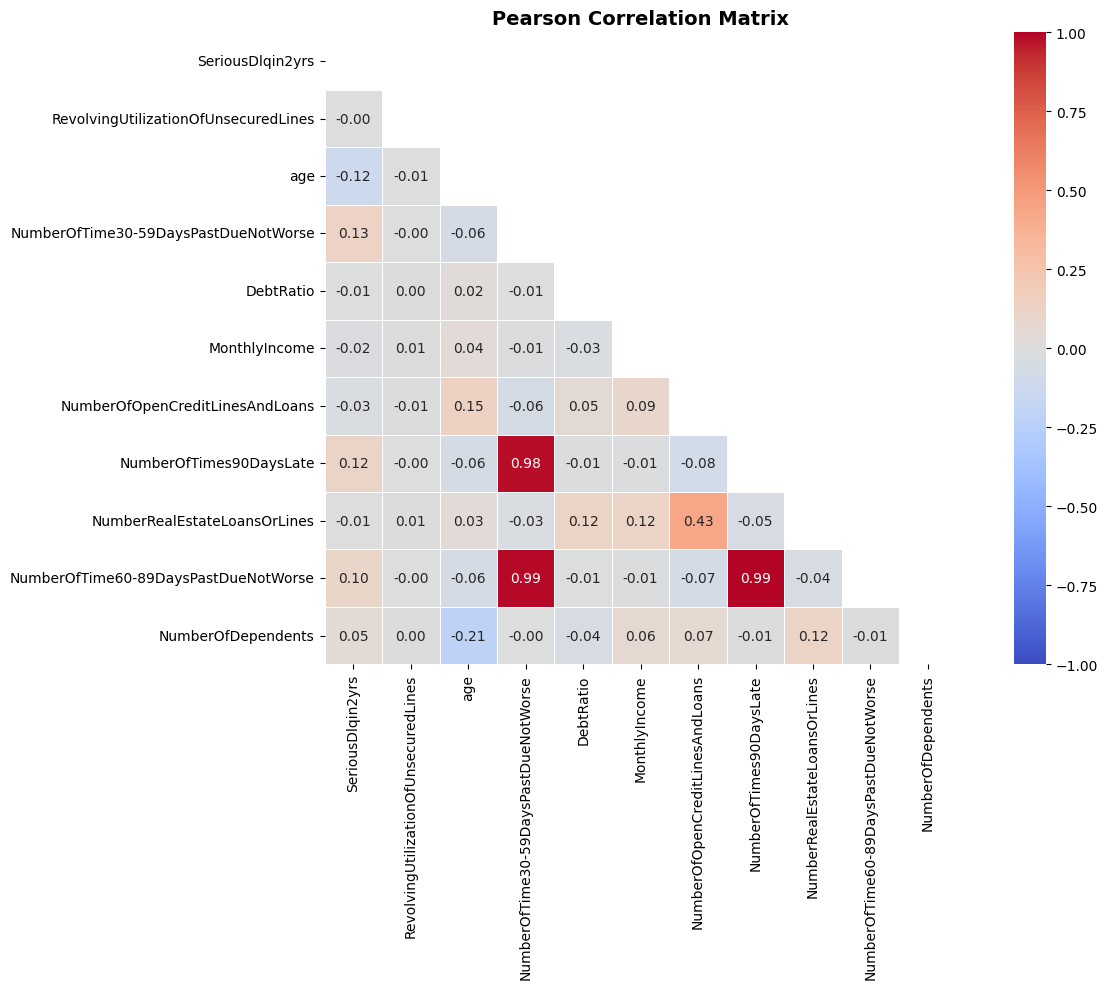

In [41]:
# Full correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

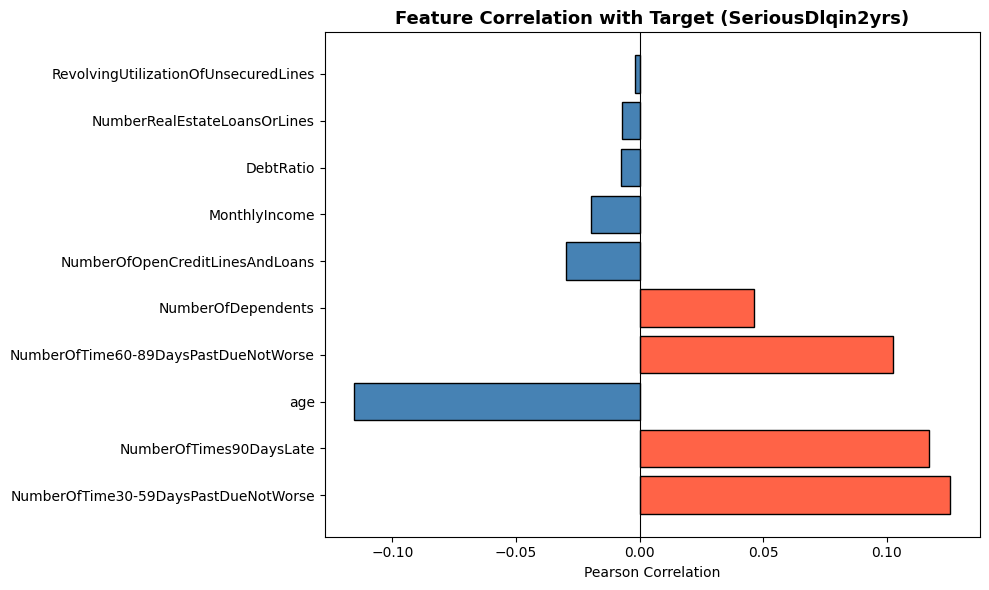

NumberOfTime30-59DaysPastDueNotWorse    0.1256
NumberOfTimes90DaysLate                 0.1172
age                                    -0.1154
NumberOfTime60-89DaysPastDueNotWorse    0.1023
NumberOfDependents                      0.0460
NumberOfOpenCreditLinesAndLoans        -0.0297
MonthlyIncome                          -0.0197
DebtRatio                              -0.0076
NumberRealEstateLoansOrLines           -0.0070
RevolvingUtilizationOfUnsecuredLines   -0.0018
Name: SeriousDlqin2yrs, dtype: float64


In [49]:
# Correlation with target, ranked
target_corr = corr_matrix['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors_bar = ['tomato' if x > 0 else 'steelblue' for x in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target (SeriousDlqin2yrs)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(target_corr)

In [57]:
# Identify highly correlated feature pairs (excluding target)
threshold = 0.7
high_corr_pairs = []

feature_corr = df[features].corr()

for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        val = feature_corr.iloc[i, j]
        if abs(val) >= threshold:
            high_corr_pairs.append({
                'Feature A': feature_corr.columns[i],
                'Feature B': feature_corr.columns[j],
                'Correlation': round(val, 4)
            })

if high_corr_pairs:
    print(f'Feature pairs with |correlation| >= {threshold}:')
    display(pd.DataFrame(high_corr_pairs))
else:
    print(f'No feature pairs found with |correlation| >= {threshold}')

Feature pairs with |correlation| >= 0.7:


,Feature A,Feature B,Correlation
0,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,0.9836
1,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,0.9870
2,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,0.9928


**Observations:**

*(Which features are most correlated with the target? Which feature pairs are highly correlated with each other? What does this mean for model choice and feature selection?)*

---
## Task 8: Feature vs. Target Relationship

Correlation gives a single number but it does not tell the full story. Here we look at how each feature's distribution actually differs between the two classes. This is one of the most informative steps in EDA for a classification problem because it directly shows which features separate defaulters from non-defaulters.

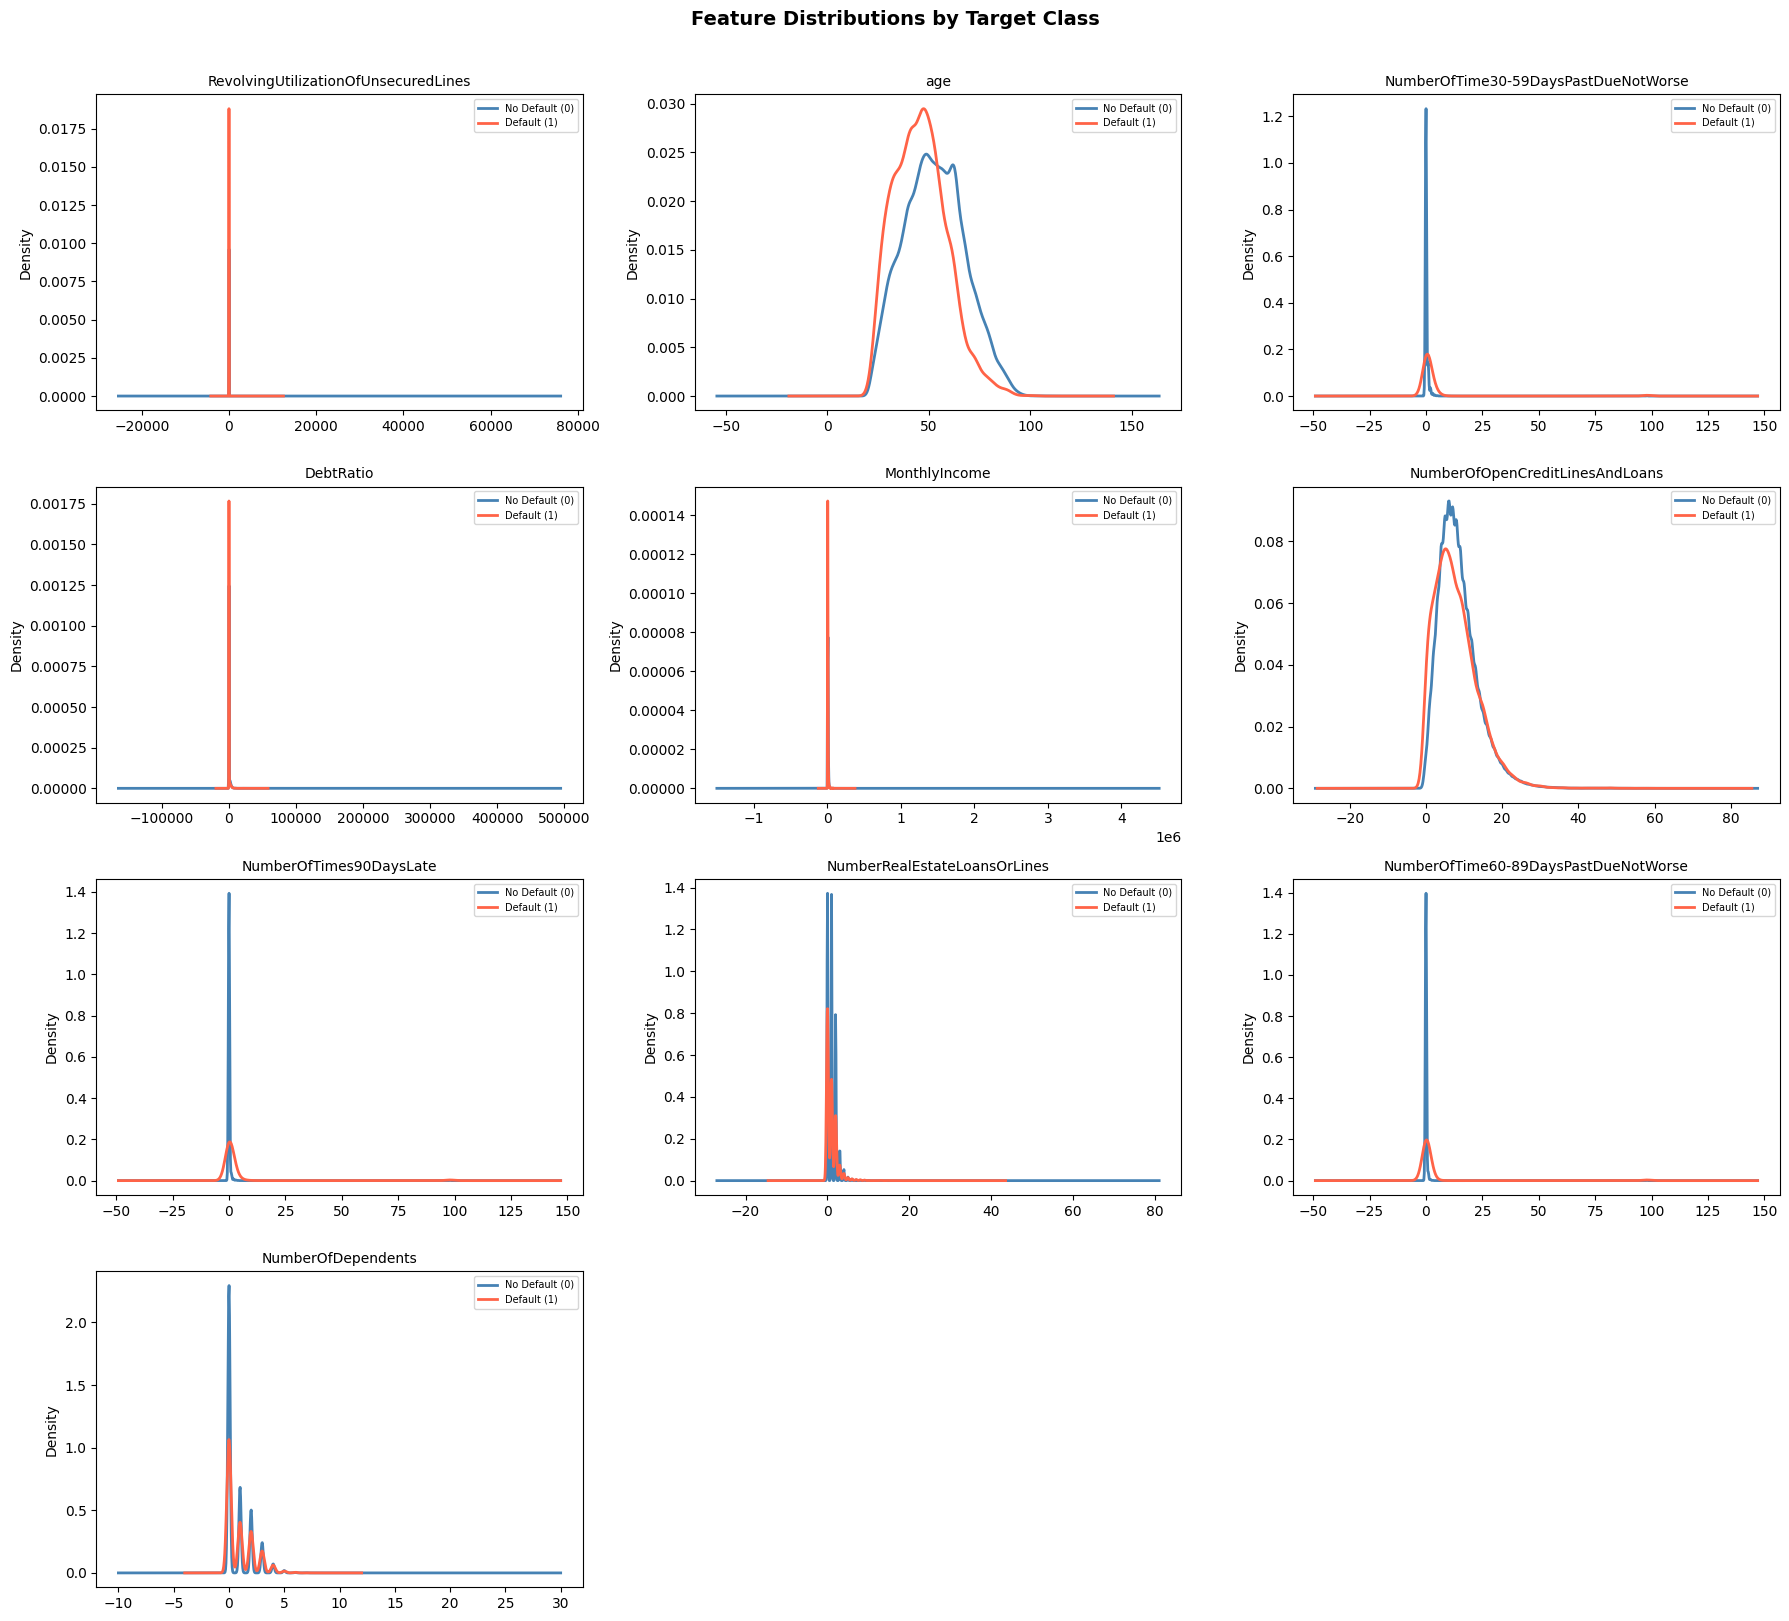

In [58]:
# Overlapping KDE plots split by target class
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    class0 = df[df['SeriousDlqin2yrs'] == 0][col].dropna()
    class1 = df[df['SeriousDlqin2yrs'] == 1][col].dropna()

    try:
        class0.plot.kde(ax=axes[i], label='No Default (0)', color='steelblue', linewidth=2)
        class1.plot.kde(ax=axes[i], label='Default (1)', color='tomato', linewidth=2)
    except Exception:
        axes[i].hist(class0, bins=30, alpha=0.5, label='No Default (0)', color='steelblue', density=True)
        axes[i].hist(class1, bins=30, alpha=0.5, label='Default (1)', color='tomato', density=True)

    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Density')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Target Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

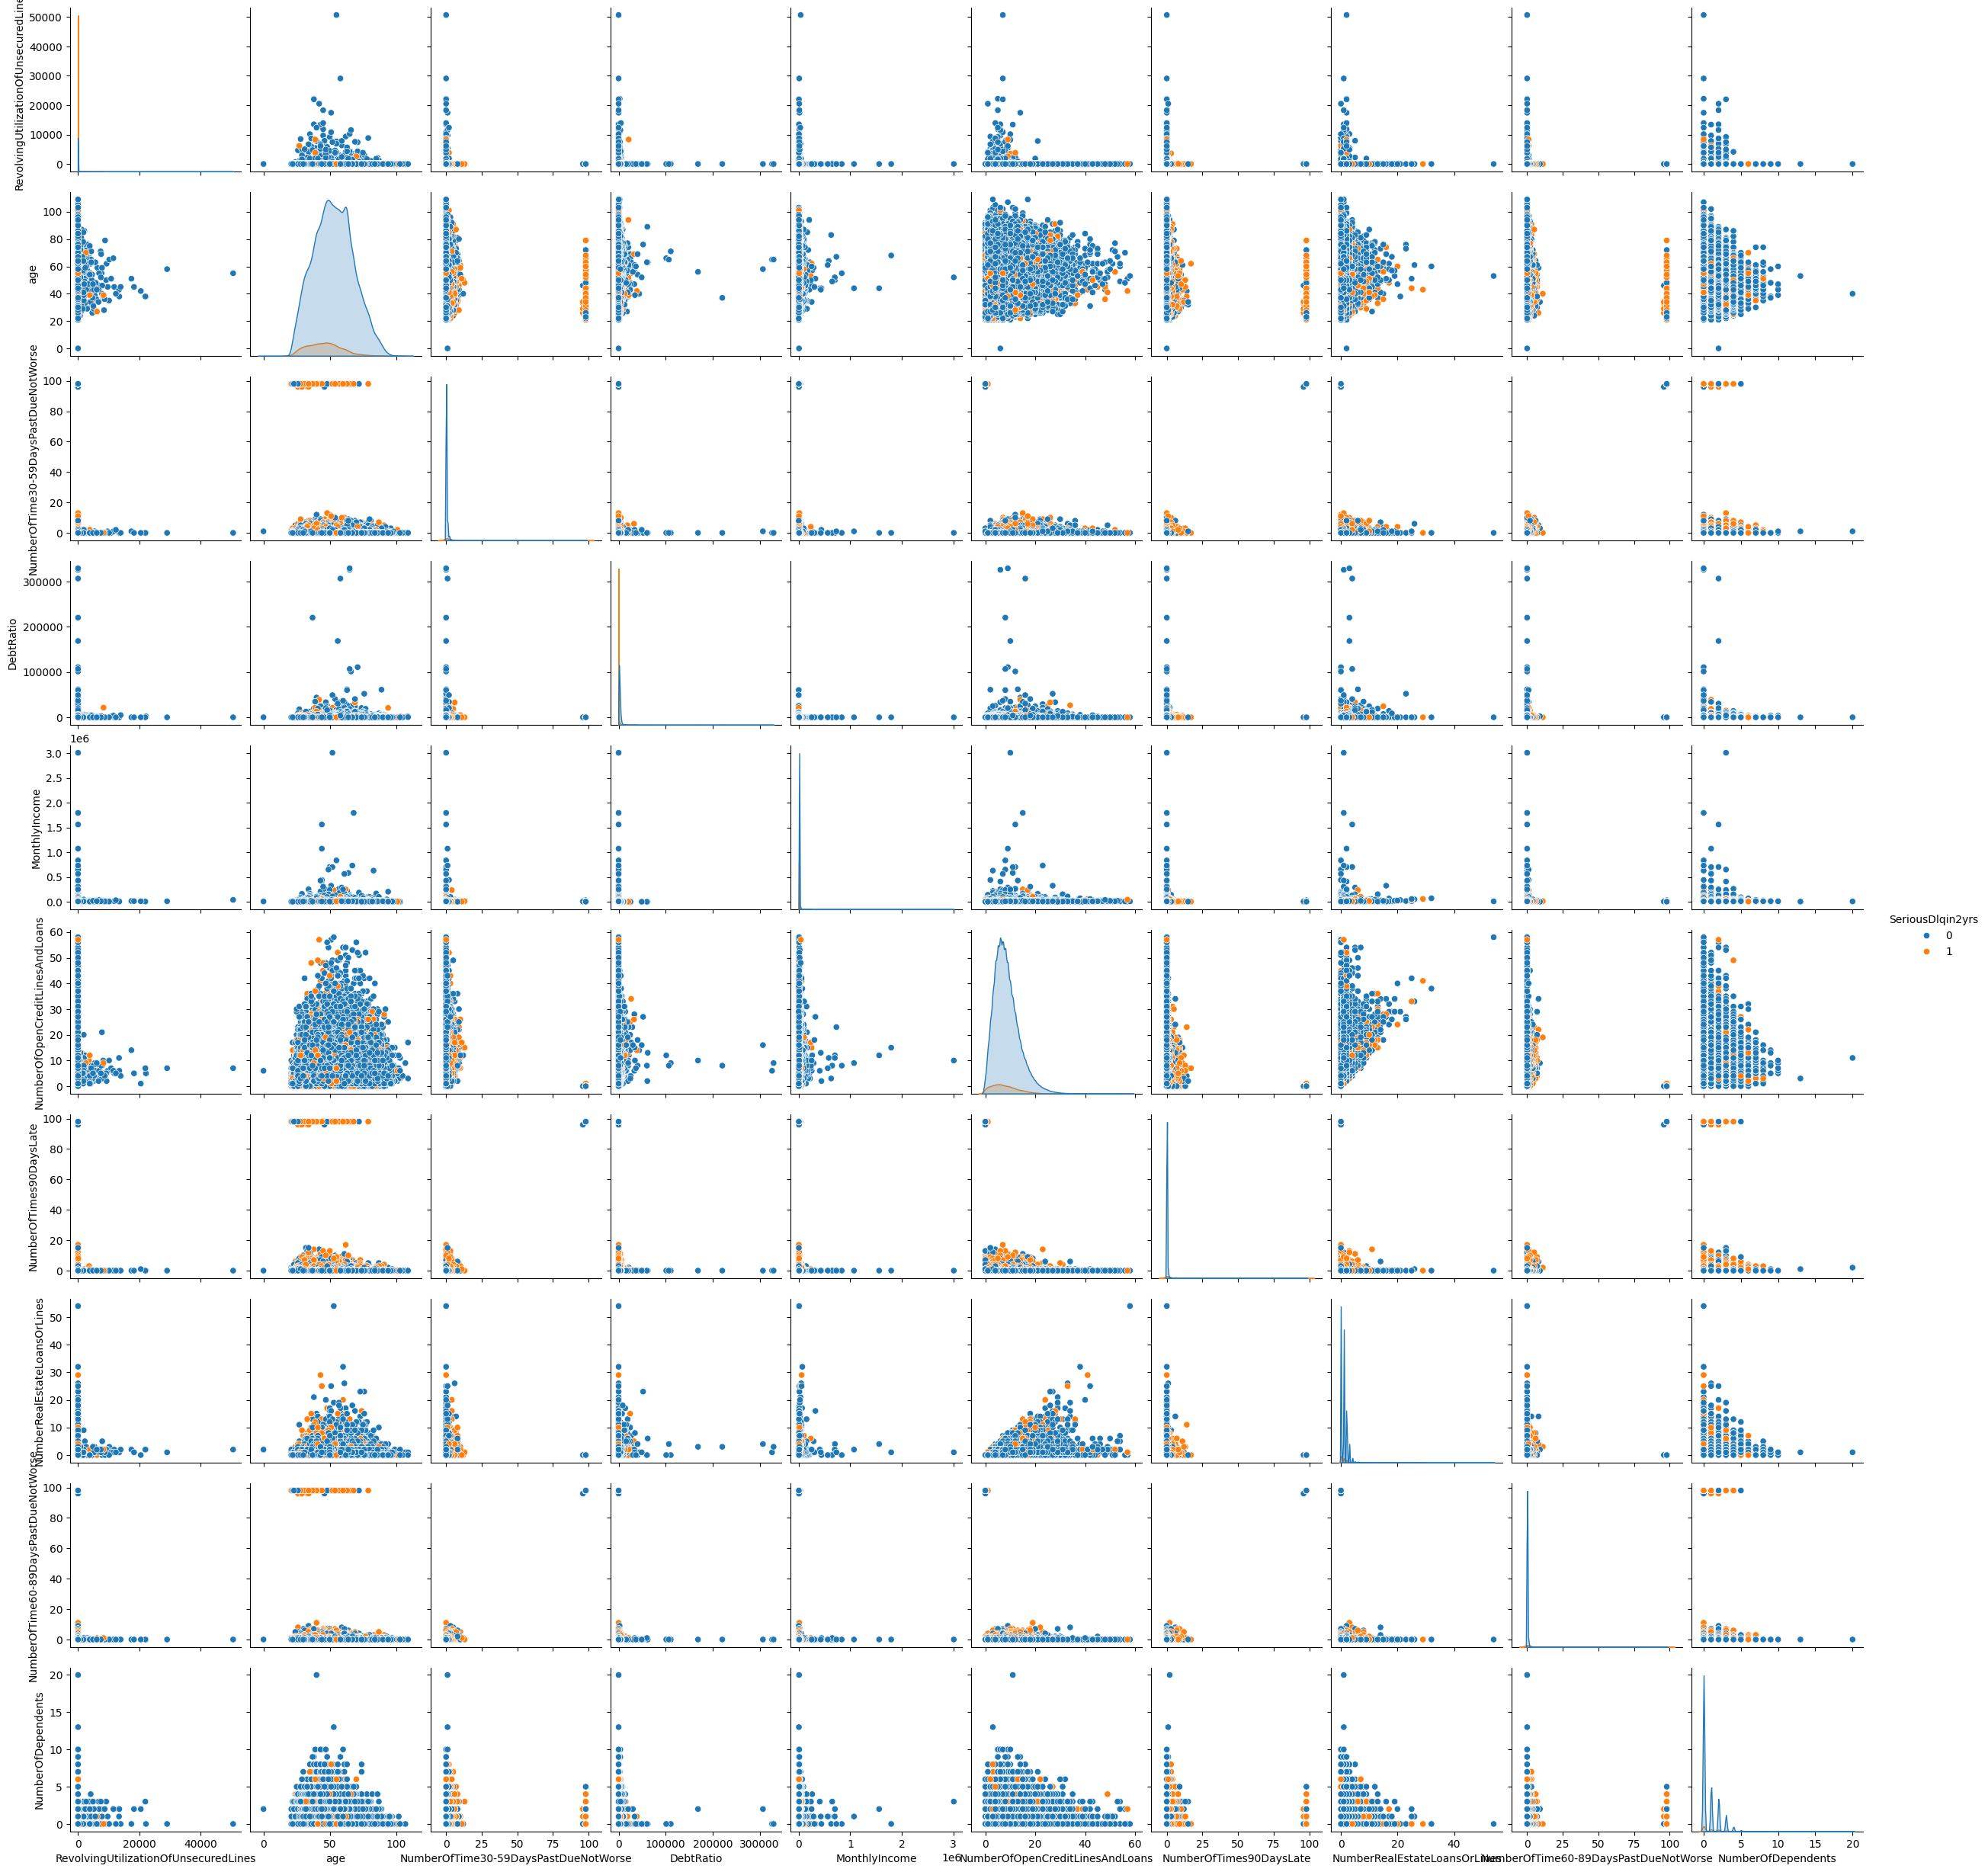

In [86]:
sns.pairplot(df, hue = 'SeriousDlqin2yrs')

In [59]:
# Mean and median per feature grouped by target class
grouped_stats = df.groupby('SeriousDlqin2yrs')[features].agg(['mean', 'median'])
print(grouped_stats.T)

SeriousDlqin2yrs                                    0         1
RevolvingUtilizationOfUnsecuredLines mean      6.1689    4.3673
                                     median    0.1333    0.8389
age                                  mean     52.7514   45.9266
                                     median   52.0000   45.0000
NumberOfTime30-59DaysPastDueNotWorse mean      0.2801    2.3885
                                     median    0.0000    0.0000
DebtRatio                            mean    357.1512  295.1211
                                     median    0.3627    0.4282
MonthlyIncome                        mean   6747.8378 5630.8265
                                     median 5466.0000 4500.0000
NumberOfOpenCreditLinesAndLoans      mean      8.4936    7.8823
                                     median    8.0000    7.0000
NumberOfTimes90DaysLate              mean      0.1352    2.0914
                                     median    0.0000    0.0000
NumberRealEstateLoansOrLines         mea

**Observations:**

*(Which features show the clearest difference between the two classes? Which features look nearly identical across classes? What does the direction of the relationship tell you?)*

---
## Task 9: Cardinality Check

A cardinality check looks at how many unique values each column contains. A numerical column with only three or four unique values is probably better treated as categorical. This affects how the feature is encoded and how a model interprets it.

In [61]:
cardinality = pd.DataFrame({
    'Unique Values': df.nunique(),
    'Dtype': df.dtypes,
    'Sample Values': [sorted(df[col].dropna().unique())[:10] for col in df.columns]
})

cardinality

,Unique Values,Dtype,Sample Values
SeriousDlqin2yrs,2,int64,"[0, 1]"
RevolvingUtilizationOfUnsecuredLines,125728,float64,"[0.0, 8.37e-06, 9.93e-06, 1.25e-05, 1.43e-05, ..."
age,86,int64,"[0, 21, 22, 23, 24, 25, 26, 27, 28, 29]"
NumberOfTime30-59DaysPastDueNotWorse,16,int64,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
DebtRatio,114194,float64,"[0.0, 2.6e-05, 3.69e-05, 3.93e-05, 6.62e-05, 7..."
MonthlyIncome,13594,float64,"[0.0, 1.0, 2.0, 4.0, 5.0, 7.0, 9.0, 10.0, 11.0..."
NumberOfOpenCreditLinesAndLoans,58,int64,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
NumberOfTimes90DaysLate,19,int64,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
NumberRealEstateLoansOrLines,28,int64,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
NumberOfTime60-89DaysPastDueNotWorse,13,int64,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"


In [62]:
# Flag columns with low cardinality (fewer than 10 unique values)
low_cardinality = cardinality[cardinality['Unique Values'] < 10]
print('Low cardinality columns (fewer than 10 unique values):')
print(low_cardinality)

Low cardinality columns (fewer than 10 unique values):
                  Unique Values  Dtype Sample Values
SeriousDlqin2yrs              2  int64        [0, 1]


In [63]:
# Value count distribution for each low-cardinality column
for col in low_cardinality.index:
    if col != 'SeriousDlqin2yrs':
        print(f'\nValue counts for: {col}')
        print(df[col].value_counts(dropna=False))

**Observations:**

*(Are there any numerical columns that behave like categorical ones? Should any of them be re-encoded? Do the value counts for low-cardinality columns look reasonable?)*

---
## Task 10: Duplicate Row Analysis

Duplicate rows inflate the dataset artificially and can bias model training by overrepresenting certain observations. If an ID column exists, duplicate IDs are a separate and more serious concern because they suggest the same individual appears more than once when they should not.

In [65]:
df.head(1)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000


In [64]:
# Exact duplicate rows
n_duplicates = df.duplicated().sum()
print(f'Number of exact duplicate rows: {n_duplicates}')
print(f'Percentage of total rows: {round(n_duplicates / len(df) * 100, 3)}%')

Number of exact duplicate rows: 609
Percentage of total rows: 0.406%


In [68]:
# View a sample of duplicates if they exist
if n_duplicates > 0:
    print('\nSample of duplicate rows:')
    duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
    display(duplicate_rows.head(20))
else:
    print('No duplicate rows found.')


Sample of duplicate rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
134366,0,0.0000,21,0,0.0000,0.0000,1,0,0,0,0.0000
137103,0,0.0000,21,0,0.0000,0.0000,1,0,0,0,0.0000
25633,0,0.0000,21,0,0.0000,820.0000,2,0,0,0,0.0000
83553,0,0.0000,21,0,0.0000,820.0000,2,0,0,0,0.0000
139346,0,0.0000,21,0,0.0000,820.0000,2,0,0,0,0.0000
100595,0,0.0000,21,0,0.0000,NaN,1,0,0,0,0.0000
127725,0,0.0000,21,0,0.0000,NaN,1,0,0,0,0.0000
44007,0,0.0000,22,0,0.0000,0.0000,1,0,0,0,0.0000
54654,0,0.0000,22,0,0.0000,0.0000,1,0,0,0,0.0000
53013,0,0.0000,22,0,0.0000,1.0000,2,0,0,0,0.0000


In [69]:
# Check if the index (ID) has duplicates
n_dup_index = df.index.duplicated().sum()
print(f'Number of duplicate index values: {n_dup_index}')

Number of duplicate index values: 0


**Observations:**

*(Are there duplicate rows? Are there duplicate IDs? If yes, do you know why they might exist? What would you do with them before modelling?)*

---
## Task 12: Skewness and Kurtosis Measurement

Visually inspecting distributions gives an impression of skewness, but actually computing the values makes it objective. Skewness measures asymmetry. Kurtosis measures tail heaviness. Having these as numbers rather than impressions allows you to make defensible decisions about transformations in the modelling phase.

In [70]:
skew_kurt = pd.DataFrame({
    'Skewness': df[features].skew(),
    'Kurtosis': df[features].kurtosis()
})

# Categorize skewness
def skew_label(s):
    if abs(s) < 0.5:
        return 'Low'
    elif abs(s) < 1.0:
        return 'Moderate'
    else:
        return 'High'

skew_kurt['Skew Level'] = skew_kurt['Skewness'].apply(skew_label)
skew_kurt = skew_kurt.sort_values('Skewness', ascending=False)
print(skew_kurt)

                                      Skewness   Kurtosis Skew Level
MonthlyIncome                         114.0403 19504.7054       High
RevolvingUtilizationOfUnsecuredLines   97.6316 14544.7134       High
DebtRatio                              95.1578 13734.2889       High
NumberOfTime60-89DaysPastDueNotWorse   23.3317   545.6827       High
NumberOfTimes90DaysLate                23.0873   537.7389       High
NumberOfTime30-59DaysPastDueNotWorse   22.5971   522.3765       High
NumberRealEstateLoansOrLines            3.4825    60.4768       High
NumberOfDependents                      1.5882     3.0017       High
NumberOfOpenCreditLinesAndLoans         1.2153     3.0911       High
age                                     0.1890    -0.4947        Low


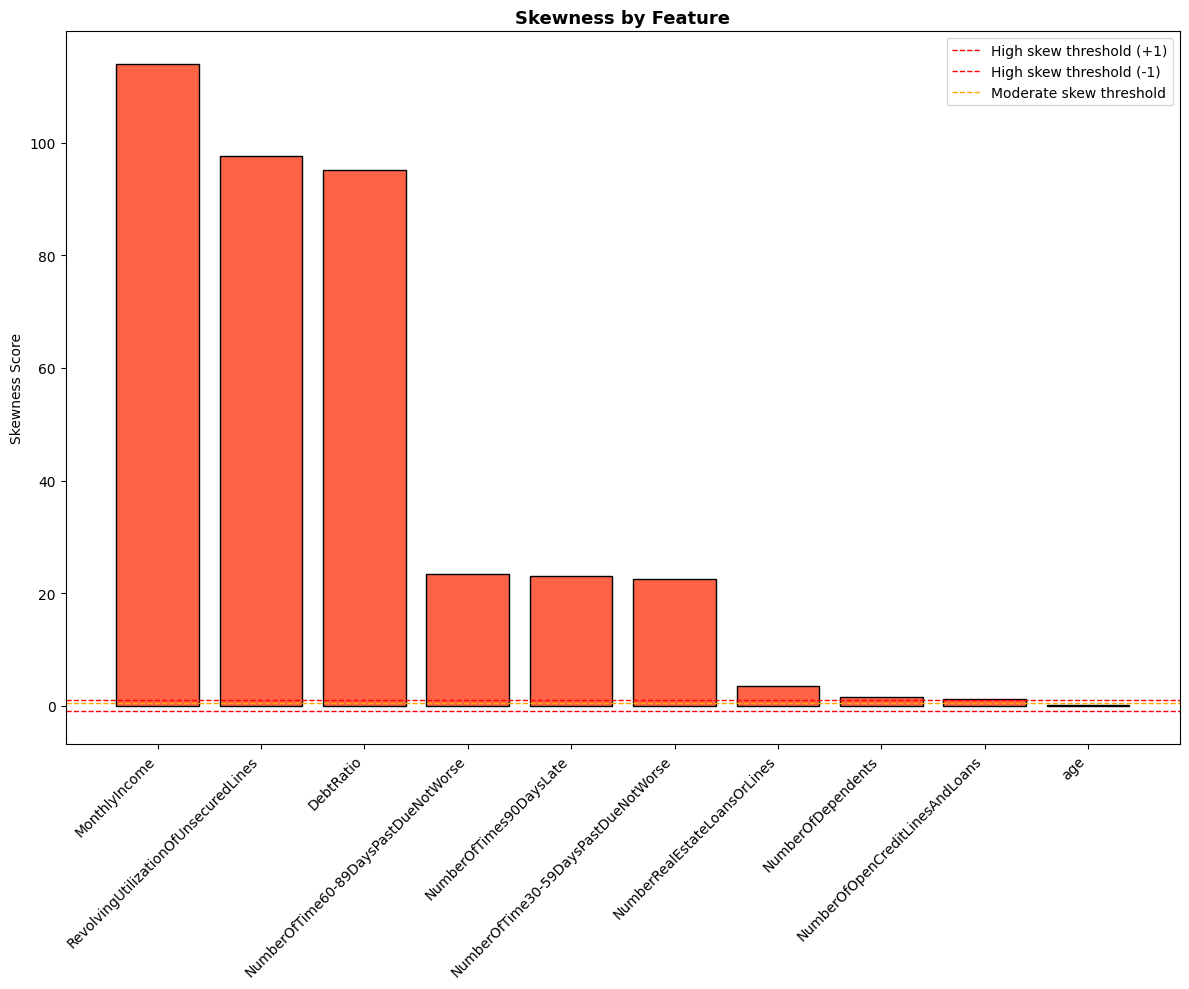

In [72]:
# Visualize skewness scores
plt.figure(figsize=(12, 10))
colors_skew = ['tomato' if abs(s) >= 1 else 'orange' if abs(s) >= 0.5 else 'steelblue'
               for s in skew_kurt['Skewness']]
plt.bar(skew_kurt.index, skew_kurt['Skewness'], color=colors_skew, edgecolor='black')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1, label='High skew threshold (+1)')
plt.axhline(y=-1, color='red', linestyle='--', linewidth=1, label='High skew threshold (-1)')
plt.axhline(y=0.5, color='orange', linestyle='--', linewidth=1, label='Moderate skew threshold')
plt.xticks(rotation=45, ha='right')
plt.title('Skewness by Feature', fontsize=13, fontweight='bold')
plt.ylabel('Skewness Score')
plt.legend()
plt.tight_layout()
plt.show()

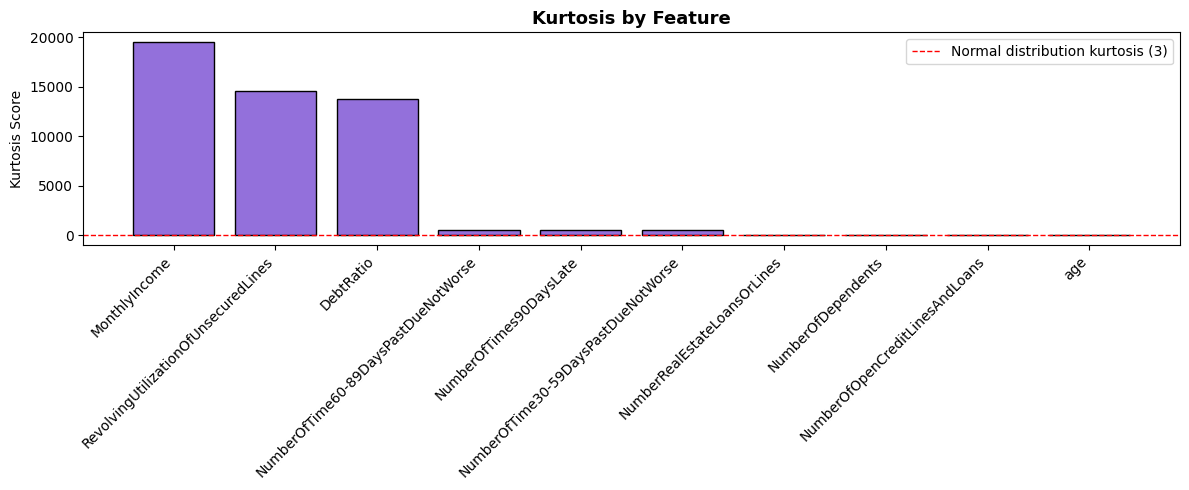

In [73]:
# Visualize kurtosis scores
plt.figure(figsize=(12, 5))
plt.bar(skew_kurt.index, skew_kurt['Kurtosis'], color='mediumpurple', edgecolor='black')
plt.axhline(y=3, color='red', linestyle='--', linewidth=1, label='Normal distribution kurtosis (3)')
plt.xticks(rotation=45, ha='right')
plt.title('Kurtosis by Feature', fontsize=13, fontweight='bold')
plt.ylabel('Kurtosis Score')
plt.legend()
plt.tight_layout()
plt.show()

**Observations:**

*(Which features have high skewness? Which ones have extreme kurtosis? How does this inform your decision about transformation and model selection?)*

---
## Task 13: Missing Data Predictiveness Check

This step asks a simple but important question: is the fact that a value is missing related to the outcome? If the default rate is noticeably different between rows with and without a value, then the missingness itself is informative. Simply imputing the missing values without flagging them would throw away that information.

In [74]:
cols_with_missing = df.columns[df.isnull().any()].tolist()
cols_with_missing = [c for c in cols_with_missing if c != 'SeriousDlqin2yrs']

if cols_with_missing:
    for col in cols_with_missing:
        missing_flag = df[col].isnull().astype(int)
        
        default_rate_present = df.loc[missing_flag == 0, 'SeriousDlqin2yrs'].mean()
        default_rate_missing = df.loc[missing_flag == 1, 'SeriousDlqin2yrs'].mean()
        
        count_present = (missing_flag == 0).sum()
        count_missing = (missing_flag == 1).sum()
        
        print(f'Column: {col}')
        print(f'  Present  -> Count: {count_present:,}  |  Default Rate: {default_rate_present:.4f} ({default_rate_present*100:.2f}%)')
        print(f'  Missing  -> Count: {count_missing:,}  |  Default Rate: {default_rate_missing:.4f} ({default_rate_missing*100:.2f}%)')
        print(f'  Difference in default rate: {abs(default_rate_present - default_rate_missing):.4f}')
        print()
else:
    print('No missing values found in feature columns.')

Column: MonthlyIncome
  Present  -> Count: 120,269  |  Default Rate: 0.0695 (6.95%)
  Missing  -> Count: 29,731  |  Default Rate: 0.0561 (5.61%)
  Difference in default rate: 0.0133

Column: NumberOfDependents
  Present  -> Count: 146,076  |  Default Rate: 0.0674 (6.74%)
  Missing  -> Count: 3,924  |  Default Rate: 0.0456 (4.56%)
  Difference in default rate: 0.0218



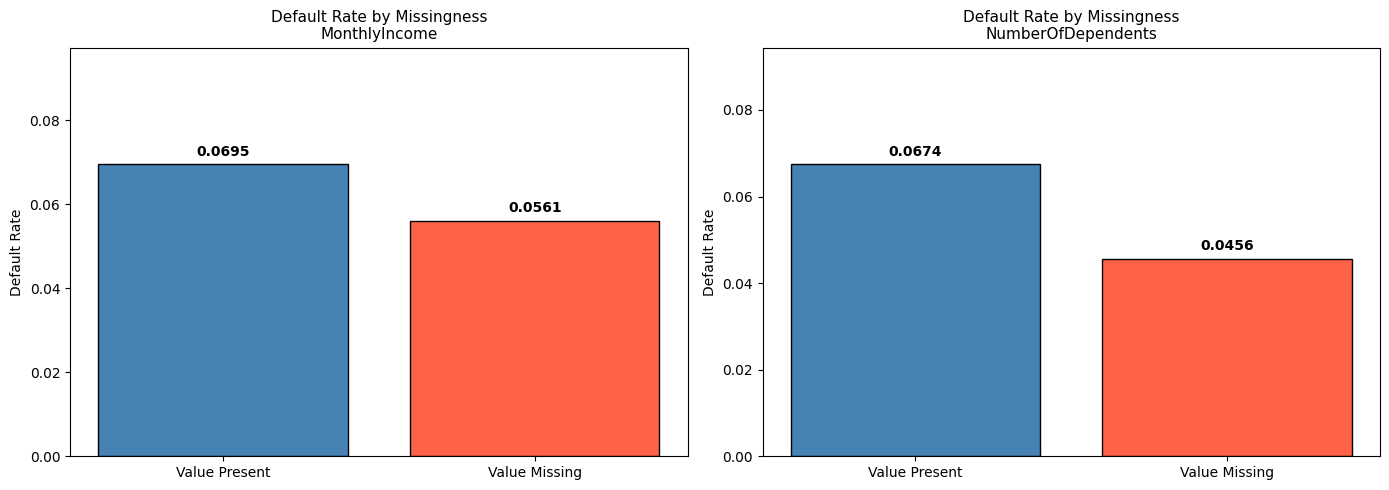

In [75]:
# Visualize the difference in default rate between present and missing
if cols_with_missing:
    fig, axes = plt.subplots(1, len(cols_with_missing), figsize=(7 * len(cols_with_missing), 5))
    if len(cols_with_missing) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols_with_missing):
        missing_flag = df[col].isnull().astype(int)
        rates = [
            df.loc[missing_flag == 0, 'SeriousDlqin2yrs'].mean(),
            df.loc[missing_flag == 1, 'SeriousDlqin2yrs'].mean()
        ]
        ax.bar(['Value Present', 'Value Missing'], rates, color=['steelblue', 'tomato'], edgecolor='black')
        ax.set_title(f'Default Rate by Missingness\n{col}', fontsize=11)
        ax.set_ylabel('Default Rate')
        ax.set_ylim(0, max(rates) * 1.4)
        for i, v in enumerate(rates):
            ax.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

**Observations:**

*(Is the default rate different between rows where values are present vs missing? Is the difference large enough to be meaningful? What does this tell you about how you should handle these missing values during preprocessing?)*

---
## Task 14: Constant and Quasi-Constant Feature Check

A feature that never changes provides zero information to any model. It cannot help separate the two classes because it looks identical for every row. Quasi-constant features, where one value makes up almost all of the rows, are nearly as uninformative. Both should be identified and evaluated before modelling.

In [76]:
# Constant features: only one unique value
constant_features = [col for col in df.columns if df[col].nunique(dropna=True) == 1]
print(f'Constant features (1 unique value): {constant_features}')

Constant features (1 unique value): []


In [77]:
# Quasi-constant features: one value dominates above a threshold
threshold = 0.95

quasi_constant = []
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq >= threshold:
        quasi_constant.append({
            'Feature': col,
            'Dominant Value': df[col].value_counts(dropna=False).index[0],
            'Dominant Pct': round(top_freq * 100, 3)
        })

quasi_df = pd.DataFrame(quasi_constant)
print(f'Quasi-constant features (one value >= {threshold*100}% of rows):')
print(quasi_df)

Quasi-constant features (one value >= 95.0% of rows):
Empty DataFrame
Columns: []
Index: []


In [84]:
# For quasi-constant features, check if the rare category is meaningful
# Look at the default rate of the rare vs dominant category
quasi_features = [row['Feature'] for _, row in quasi_df.iterrows()
                  if row['Feature'] != 'SeriousDlqin2yrs']

for col in quasi_features:
    dominant_val = df[col].value_counts(dropna=False).index[0]
    dominant_rate = df.loc[df[col] == dominant_val, 'SeriousDlqin2yrs'].mean()
    rare_rate = df.loc[df[col] != dominant_val, 'SeriousDlqin2yrs'].mean()
    rare_count = (df[col] != dominant_val).sum()
    
    print(f'Column: {col}')
    print(f'  Dominant value ({dominant_val}) -> Default Rate: {dominant_rate:.4f}')
    print(f'  Rare values (n={rare_count}) -> Default Rate: {rare_rate:.4f}')
    print()

**Observations:**

*(Are there any constant or quasi-constant features? For quasi-constant features, does the rare category have a meaningfully different default rate? Does that change your decision about whether to keep or drop the feature?)*

---
## EDA Summary

Use this section to consolidate what you found across all tasks. This is not a place for code. It is a place to record conclusions and the decisions they lead to.

**Key findings from the data:**

*(Summarize the most important things you found. What are the biggest data quality issues? Which features stand out as strong or weak predictors? What surprised you?)*

---

**Problems identified and how they will be handled:**

*(List the specific issues you found and what you plan to do about each one before modelling.)*

---

**Decisions carried into modelling:**

*(Based on what you found, what modelling decisions are already taking shape? For example: which metric to use, which model types are better suited to this data, which features need transformation, which features look most promising.)*